# LeNet-5 Plus Evaluation and Visualization

In [2]:
import os
import sys

import pandas as pd
import tensorflow as tf

# Add the parent directory to the Python path to allow imports from sibling directories
sys.path.append(os.path.abspath(".."))

from data.dataset import prepare_mnist_dataset, prepare_cifar10_dataset
from models.lenet5 import LeNet5
from utils.trainer import LeNetTrainer
from utils.visualize import plot_training_hist_df, plot_confusion_matrix, plot_sample_predictions

# Check TensorFlow version and available devices
print("TensorFlow Version:", tf.__version__)
print("Devices available:", tf.config.list_physical_devices())

TensorFlow Version: 2.21.0
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Evaluation on CIFAR-10 dataset

In [3]:
DATASET_NAME = "cifar10"
BATCH_SIZE = 64

_, _, test_ds = prepare_cifar10_dataset(batch_size=BATCH_SIZE)
input_shape = (32, 32, 3)

print(f"\nSuccessfully loaded CIFAR-10 data pipelines.")

CIFAR-10 Shapes: (50000, 32, 32, 3) (50000,) (10000, 32, 32, 3) (10000,)

Successfully loaded CIFAR-10 data pipelines.


In [6]:
# Paths for saved model and weights
BEST_MODEL_PATH_CIF = f"../saved_models/lenet5_{DATASET_NAME}_best_model.keras"

# Option A: Load full saved model (.keras)
if os.path.exists(BEST_MODEL_PATH_CIF):
    model = tf.keras.models.load_model(BEST_MODEL_PATH_CIF)
    print("Best model loaded successfully.")
else:
    raise FileNotFoundError("No saved model or weights found. Please train the model first.")

Best model loaded successfully.


In [7]:
# Display network architecture summary
model.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C1_Conv (Conv2D)                │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2_MaxPool (MaxPooling2D)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3_Conv (Conv2D)                │ (None, 10, 10, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4_MaxPool (MaxPooling2D)       │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5_Conv (Conv2D)                │ (None, 1, 1, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 1, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6_Dense (Dense)                │ (None, 84)             │        10,836 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 812,724 (3.10 MB)

 Trainable params: 270,758 (1.03 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 541,518 (2.07 MB)

Training history loaded successfully.


,epoch,accuracy,loss,top_5_accuracy,val_accuracy,val_loss,val_top_5_accuracy
0,0,0.400778,1.636320,0.887267,0.5330,1.297235,0.9458
1,1,0.502889,1.380724,0.931067,0.4528,1.667443,0.8690
2,0,0.404733,1.624957,0.626289,0.4842,1.428580,0.6804
3,1,0.505956,1.376508,0.717222,0.4400,1.661581,0.6258
4,2,0.546511,1.269576,0.749689,0.4958,1.448786,0.7092


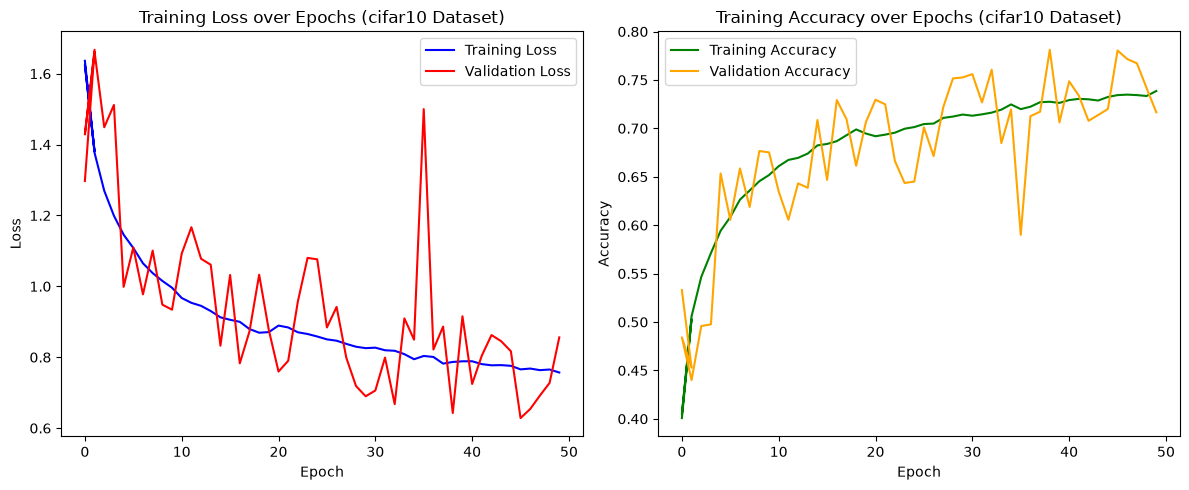

In [9]:
HISTORY_PATH = f"../saved_models/lenet5_{DATASET_NAME}_history.csv"

if os.path.exists(HISTORY_PATH):
    # Load history from CSV file into a Pandas DataFrame
    history_df = pd.read_csv(HISTORY_PATH)
    print("Training history loaded successfully.")
    display(history_df.head())
else:
    raise FileNotFoundError(f"History file not found at: {HISTORY_PATH}")

# Plot training & validation loss and accuracy curves across epochs
plot_training_hist_df(history_df, dataset_name=DATASET_NAME)

In [10]:
trainer = LeNetTrainer(model=model)

# Evaluate model performance on unseen test data
results = trainer.evaluate(test_ds, dataset_name=DATASET_NAME)

print(f"Test Accuracy ({DATASET_NAME.upper()}): {results['accuracy'] * 100:.2f}%")
print(f"Test Loss ({DATASET_NAME.upper()}): {results['loss']:.4f}")

--- Evaluating LeNet-5 on (cifar10)Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - accuracy: 0.7641 - loss: 0.6884 - top_2_accuracy: 0.8942
Test Accuracy (CIFAR10): 76.41%
Test Loss (CIFAR10): 0.6884


157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 178ms/step


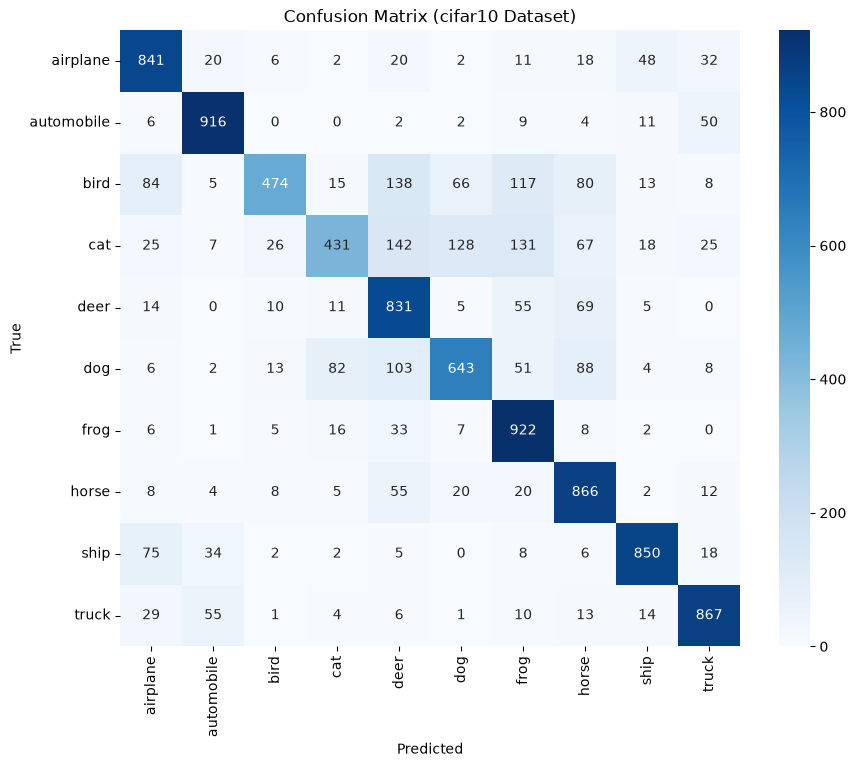

In [11]:
# Generate and display normalized confusion matrix heatmap
plot_confusion_matrix(model=model, dataset=test_ds, dataset_name=DATASET_NAME)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step


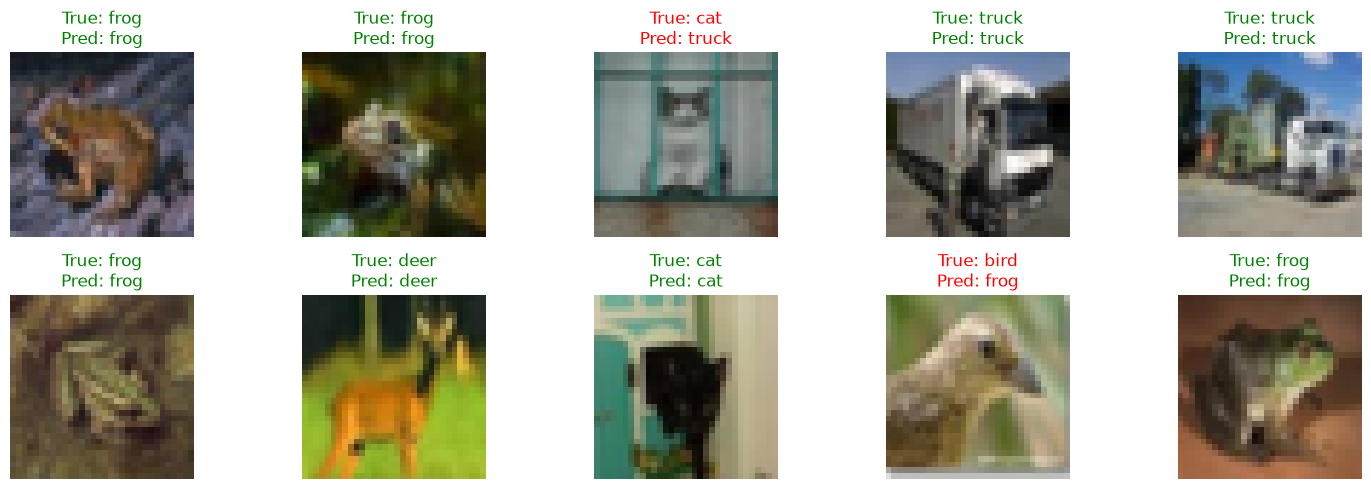

In [12]:
# Visualize random test set samples with green/red prediction status labels
plot_sample_predictions(
    model=model,
    dataset=test_ds,
    dataset_name=DATASET_NAME,
    num_samples=10
)